# Phase 3: Scenario Simulation, Sensitivity Analysis, and Forecasting

**Objective:** Transition the project from historical predictive modeling into policy-oriented scenario analysis and forward-looking forecasting.

This updated Phase 3 notebook:
- uses the **same expanded feature set** as the updated Phase 2 notebook
- loads the **Phase 2 model-selection summary** when available
- reconstructs the **best-performing tuned model** (Random Forest or HistGradientBoosting)
- runs scenario simulations and exports forecast-ready outputs


## 1. Load Processed Data and Rebuild the Best Phase 2 Model

This section reloads the processed modeling dataset created in Phase 2, checks whether a saved split column is available, and then reconstructs the **best-performing Phase 2 model** using the saved tuning metadata whenever possible.

The feature set includes:
- `vulnerability_index`
- `median_income_real`
- `max_wind_knots`
- `max_seismic_mag`
- `lag_violent_crime_rate`
- `lag_property_crime_rate`
- `lag_pop_change_1`
- `lag_pop_change_2`
- `income_growth`


In [1]:
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

data_path = Path('../data/processed_puerto_rico_data.csv')
df_clean = pd.read_csv(data_path)

required_columns = [
    'vulnerability_index',
    'median_income_real',
    'max_wind_knots',
    'max_seismic_mag',
    'lag_violent_crime_rate',
    'lag_property_crime_rate',
    'lag_pop_change_1',
    'lag_pop_change_2',
    'income_growth',
    'target_pop_change'
]

missing_required = [c for c in required_columns if c not in df_clean.columns]
if missing_required:
    raise ValueError(f"Missing required columns in processed dataset: {missing_required}")

features = [
    'vulnerability_index',
    'median_income_real',
    'max_wind_knots',
    'max_seismic_mag',
    'lag_violent_crime_rate',
    'lag_property_crime_rate',
    'lag_pop_change_1',
    'lag_pop_change_2',
    'income_growth'
]

if 'split' in df_clean.columns:
    train_mask = df_clean['split'].astype(str).str.lower().eq('train')
    test_mask = df_clean['split'].astype(str).str.lower().eq('test')
    split_method = "pre-saved split column from Phase 2"
else:
    if 'year' not in df_clean.columns:
        raise ValueError(
            "No 'split' column found and no 'year' column available for fallback time-based split."
        )
    train_end_year = 2020
    test_start_year = 2021
    train_mask = df_clean['year'] <= train_end_year
    test_mask = df_clean['year'] >= test_start_year
    split_method = f"fallback time-based split (train <= {train_end_year}, test >= {test_start_year})"

if train_mask.sum() == 0 or test_mask.sum() == 0:
    raise ValueError("Train or test set is empty. Check the split column or year coverage.")

X_train = df_clean.loc[train_mask, features].copy()
X_test = df_clean.loc[test_mask, features].copy()
y_train = df_clean.loc[train_mask, 'target_pop_change'].copy()
y_test = df_clean.loc[test_mask, 'target_pop_change'].copy()

summary_path = Path('../analysis/phase2_model_selection_summary.json')
model_summary = {}
if summary_path.exists():
    with open(summary_path, 'r') as f:
        model_summary = json.load(f)

best_model_name = model_summary.get('best_model_name', 'HistGradientBoosting (tuned)')

# Normalize Phase 2 labels and parameter keys from earlier notebook versions
if isinstance(best_model_name, str) and 'LightGBM' in best_model_name:
    best_model_name = best_model_name.replace('LightGBM', 'HistGradientBoosting')

if best_model_name == 'Random Forest (tuned)':
    params = model_summary.get('rf_best_params', {})
    best_model = RandomForestRegressor(random_state=42, n_jobs=-1, **params)
else:
    params = model_summary.get('hgb_best_params', model_summary.get('lgbm_best_params', {}))
    best_model = HistGradientBoostingRegressor(
        max_iter=300,
        random_state=42,
        **params
    )

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

eval_df = pd.DataFrame({
    'Metric': ['R-Squared', 'MAE', 'RMSE'],
    'Value': [r2, mae, rmse]
})

print(f"Split method used: {split_method}")
print(f"Reconstructed model: {best_model_name}")
display(eval_df.round(4))


Split method used: pre-saved split column from Phase 2
Reconstructed model: Random Forest (tuned)


,Metric,Value
0,R-Squared,-0.2501
1,MAE,1.7663
2,RMSE,3.1609


> The model evaluation here is shown only to confirm that the reconstructed Phase 3 environment is aligned with the tuned model selected in Phase 2. Because the selected learner may now be **Random Forest or HistGradientBoosting**, Phase 3 is intentionally model-agnostic and uses the same feature set for both scenario simulation and forecasting.


## 2. Scenario Simulation Engine

The function below is a deterministic **scenario simulation** tool. It allows us to hold the baseline test-period socioeconomic structure constant while modifying the intensity of physical or social shocks.

### Scenarios represented
- **Hurricane stress** by setting `max_wind_knots`
- **Seismic stress** by setting `max_seismic_mag`
- **Crime environment changes** by scaling lagged crime variables with `crime_multiplier`

This should be interpreted as **stress testing** rather than formal hypothesis testing. It is useful for asking structured policy questions such as:

- What happens to predicted population change if hurricane intensity rises sharply?
- How sensitive is the forecast to worsening or improving crime conditions?
- How does predicted out-migration change under severe compound-shock assumptions?

In [2]:
def simulate_scenario(
    base_data,
    hurricane_intensity=None,
    seismic_intensity=None,
    crime_multiplier=1.0,
    income_growth_shift=0.0,
    return_summary=False
):
    """Scenario simulation engine."""
    scenario_data = base_data.copy()

    if hurricane_intensity is not None:
        scenario_data['max_wind_knots'] = hurricane_intensity

    if seismic_intensity is not None:
        scenario_data['max_seismic_mag'] = seismic_intensity

    scenario_data['lag_violent_crime_rate'] = (
        scenario_data['lag_violent_crime_rate'] * crime_multiplier
    )
    scenario_data['lag_property_crime_rate'] = (
        scenario_data['lag_property_crime_rate'] * crime_multiplier
    )
    scenario_data['income_growth'] = scenario_data['income_growth'] + income_growth_shift

    predictions = best_model.predict(scenario_data[features])

    if return_summary:
        return pd.Series({
            'mean_predicted_change_pct': float(np.mean(predictions)),
            'median_predicted_change_pct': float(np.median(predictions)),
            'min_predicted_change_pct': float(np.min(predictions)),
            'max_predicted_change_pct': float(np.max(predictions))
        })

    return predictions

compound_shock = simulate_scenario(
    X_test,
    hurricane_intensity=140,
    crime_multiplier=2.0
)

print(
    "Compound stress test (140-knot hurricane, 2x crime) mean predicted change:",
    round(compound_shock.mean(), 4)
)


Compound stress test (140-knot hurricane, 2x crime) mean predicted change: -1.3224


## 2.1 Wind Sensitivity Sweep

This section evaluates how the model's average predicted population change responds as **wind intensity** increases while other features remain fixed at their test-period baseline values.

### Interpretation guidance
- This is a **sensitivity sweep**, not proof of a physical threshold.
- A sharp change in slope may suggest that the model has learned non-linear behavior.
- Any apparent "tipping point" should be described cautiously as a **model-implied threshold**, not a proven real-world cutoff.

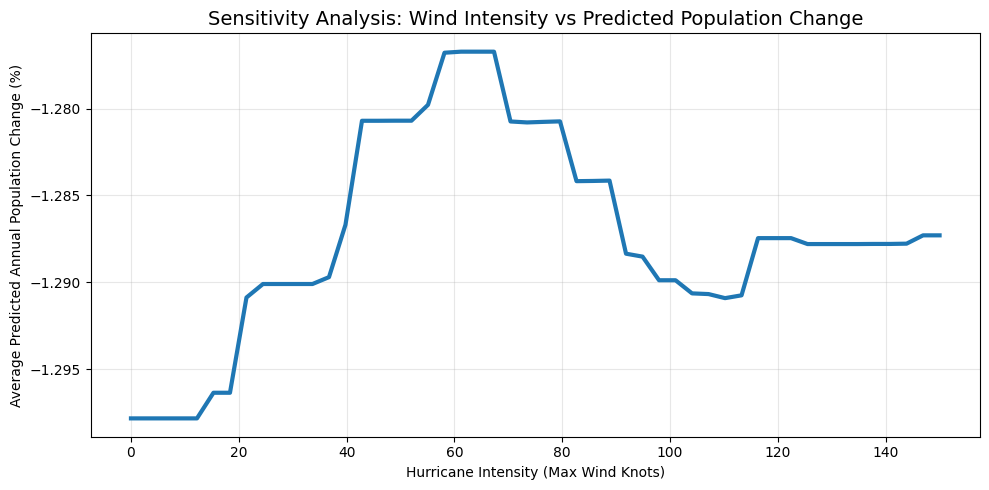

In [3]:
wind_speeds = np.linspace(0, 150, 50)
wind_sensitivities = [
    simulate_scenario(X_test, hurricane_intensity=w).mean()
    for w in wind_speeds
]

plt.figure(figsize=(10, 5))
plt.plot(wind_speeds, wind_sensitivities, linewidth=3)
plt.title("Sensitivity Analysis: Wind Intensity vs Predicted Population Change", fontsize=14)
plt.xlabel("Hurricane Intensity (Max Wind Knots)")
plt.ylabel("Average Predicted Annual Population Change (%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2.2 Seismic Sensitivity Sweep

This section repeats the same logic for **earthquake magnitude**.

Because seismic activity in Puerto Rico can be regionally concentrated, this island-wide sweep should be interpreted carefully. It is most useful as a stress-test of model behavior rather than as a literal forecast for all municipalities simultaneously.

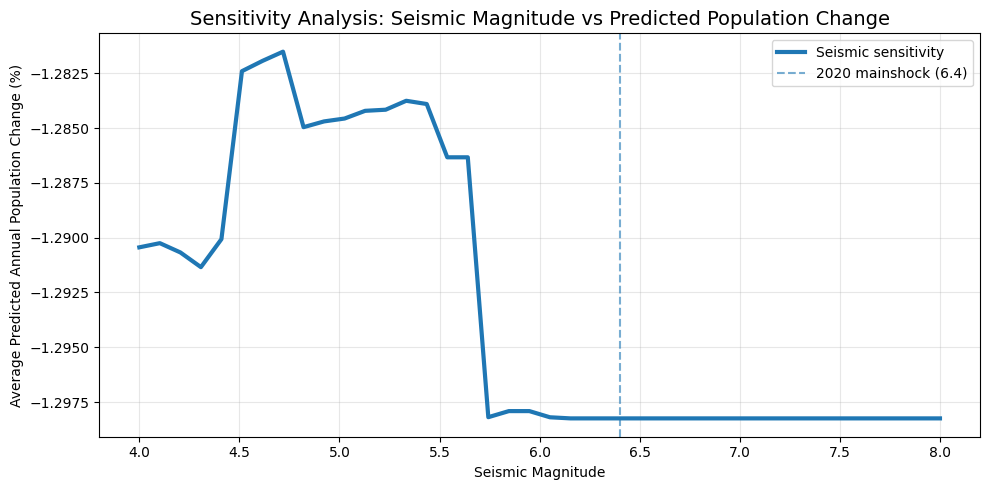

In [4]:
seismic_mags = np.linspace(4.0, 8.0, 40)
seismic_sensitivities = [
    simulate_scenario(X_test, seismic_intensity=m).mean()
    for m in seismic_mags
]

plt.figure(figsize=(10, 5))
plt.plot(seismic_mags, seismic_sensitivities, linewidth=3, label='Seismic sensitivity')
plt.axvline(x=6.4, linestyle='--', alpha=0.6, label='2020 mainshock (6.4)')
plt.title("Sensitivity Analysis: Seismic Magnitude vs Predicted Population Change", fontsize=14)
plt.xlabel("Seismic Magnitude")
plt.ylabel("Average Predicted Annual Population Change (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2.3 Crime Sensitivity Sweep

This analysis treats lagged crime rates as a policy-relevant **social shock**.

By applying a multiplier to both lagged crime variables, we can evaluate how the model responds when public safety conditions improve or deteriorate. This does **not** prove a causal policy effect; it shows how sensitive the fitted model is to changes in those inputs.

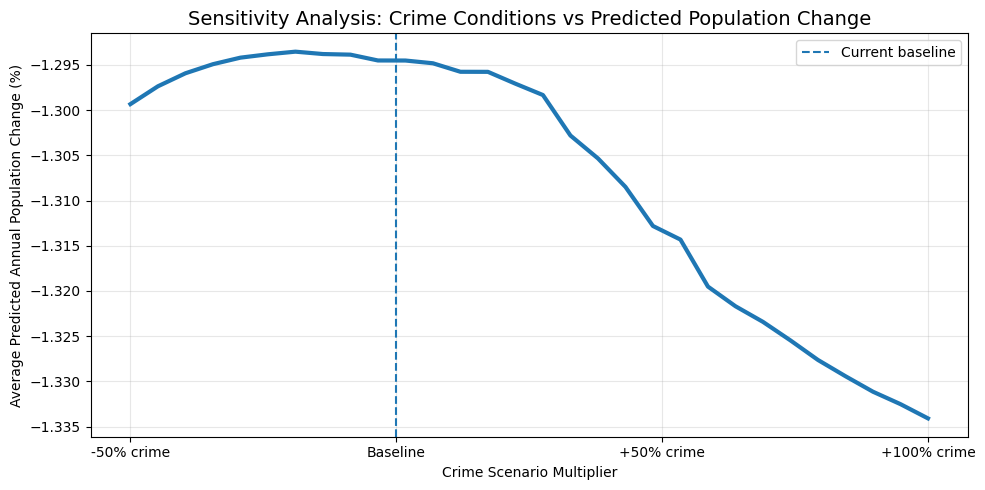

In [5]:
crime_multipliers = np.linspace(0.5, 2.0, 30)
crime_sensitivities = [
    simulate_scenario(X_test, crime_multiplier=c).mean()
    for c in crime_multipliers
]

plt.figure(figsize=(10, 5))
plt.plot(crime_multipliers, crime_sensitivities, linewidth=3)
plt.xticks(
    ticks=[0.5, 1.0, 1.5, 2.0],
    labels=['-50% crime', 'Baseline', '+50% crime', '+100% crime']
)
plt.title("Sensitivity Analysis: Crime Conditions vs Predicted Population Change", fontsize=14)
plt.xlabel("Crime Scenario Multiplier")
plt.ylabel("Average Predicted Annual Population Change (%)")
plt.axvline(x=1.0, linestyle='--', label='Current baseline')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Approximate Forecast Range from Held-Out Prediction Distribution

For a model-agnostic summary, this section uses the distribution of held-out predictions from the selected Phase 2 model. The 5th and 95th percentiles are treated as an **approximate forecast range**, not as a formal prediction interval.


In [6]:
def get_prediction_distribution_summary(model, X_data):
    """Return held-out prediction vector plus summary percentiles."""
    preds = model.predict(X_data[features])
    p05 = np.percentile(preds, 5)
    p95 = np.percentile(preds, 95)
    return preds, p05, p95

pred_distribution, pred_p05, pred_p95 = get_prediction_distribution_summary(best_model, X_test)


In [7]:
spread_summary = pd.DataFrame({
    'Statistic': [
        'Mean predicted change',
        '5th percentile of predicted change',
        '95th percentile of predicted change'
    ],
    'Value': [pred_distribution.mean(), pred_p05, pred_p95]
})

display(spread_summary.round(4))
print("Approximate prediction-distribution summary calculated successfully.")


,Statistic,Value
0,Mean predicted change,-1.2946
1,5th percentile of predicted change,-2.4472
2,95th percentile of predicted change,-0.3935


Approximate prediction-distribution summary calculated successfully.


## 4. Visualizing Prediction Distribution

The KDE plot below summarizes the distribution of held-out predicted population changes from the selected Phase 2 model, along with the 5th and 95th percentile reference lines used in the export step.


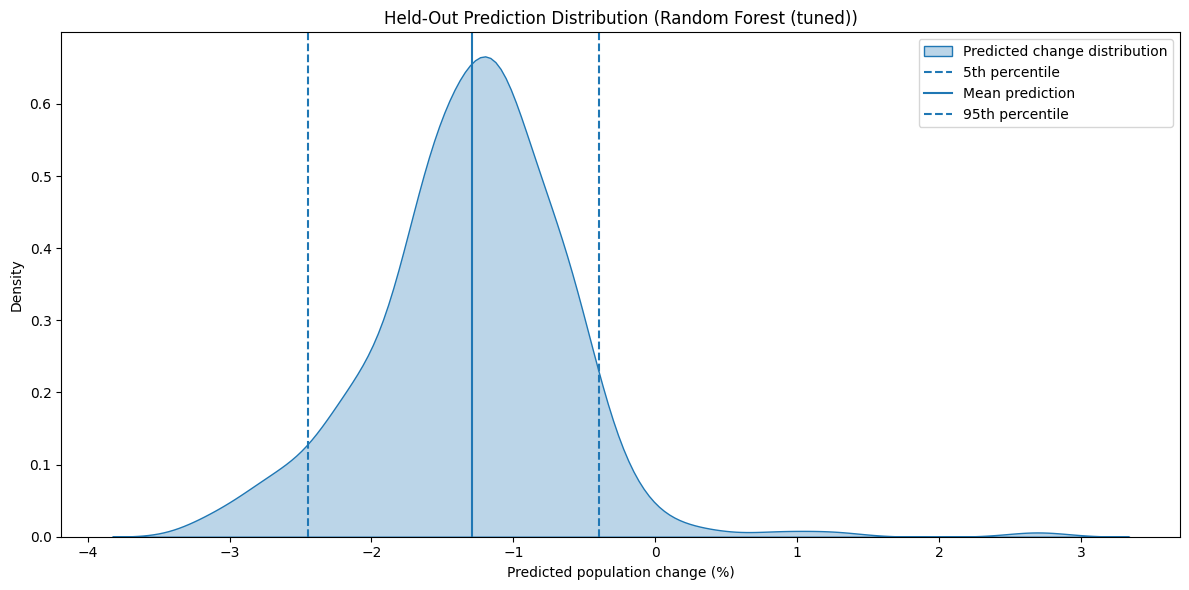

In [8]:
plt.figure(figsize=(12, 6))
sns.kdeplot(pred_distribution, label='Predicted change distribution', fill=True, alpha=0.3)
plt.axvline(pred_p05, linestyle='--', label='5th percentile')
plt.axvline(pred_distribution.mean(), linestyle='-', label='Mean prediction')
plt.axvline(pred_p95, linestyle='--', label='95th percentile')
plt.title(f'Held-Out Prediction Distribution ({best_model_name})')
plt.xlabel('Predicted population change (%)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()


## 5. Export Forecasts for Dashboard Integration

To convert percentage-change outputs into absolute population levels, this section applies the **mean**, **5th percentile**, and **95th percentile** of the held-out prediction distribution to the latest observed total population.

These bands are an **approximate scenario range** for dashboard communication, not a calibrated statistical prediction interval.


In [9]:
analysis_dir = Path('../analysis')
analysis_dir.mkdir(parents=True, exist_ok=True)

if 'total_population' in df_clean.columns and 'year' in df_clean.columns:
    latest_year = df_clean['year'].max()
    latest_population_rows = df_clean.loc[df_clean['year'] == latest_year, 'total_population']
    last_known_pop = float(latest_population_rows.sum())
else:
    raise ValueError(
        "The processed dataset must include 'year' and 'total_population' to build the export forecast."
    )

years_to_forecast = list(range(int(latest_year) + 1, int(latest_year) + 7))
forecast_results = []

current_pop_mean = last_known_pop
current_pop_low = last_known_pop
current_pop_high = last_known_pop

mean_change = float(pred_distribution.mean() / 100)
low_change = float(pred_p05 / 100)
high_change = float(pred_p95 / 100)

for year in years_to_forecast:
    current_pop_mean *= (1 + mean_change)
    current_pop_low *= (1 + low_change)
    current_pop_high *= (1 + high_change)

    forecast_results.append({
        "year": year,
        "expected": round(current_pop_mean),
        "lower_band": round(current_pop_low),
        "upper_band": round(current_pop_high)
    })

forecast_df = pd.DataFrame(forecast_results)
display(forecast_df)

output_path = analysis_dir / 'population_forecast.json'
with open(output_path, 'w') as f:
    json.dump(forecast_results, f, indent=4)

print(f"Forecast data exported successfully to: {output_path}")
print(f"Latest observed year used for baseline: {int(latest_year)}")
print(f"Baseline total population used for export: {last_known_pop:,.0f}")


,year,expected,lower_band,upper_band
0,2025,3192439,3155159,3221582
1,2026,3151110,3077945,3208905
2,2027,3110317,3002621,3196278
3,2028,3070052,2929141,3183701
4,2029,3030308,2857458,3171173
5,2030,2991079,2787530,3158695


Forecast data exported successfully to: ../analysis/population_forecast.json
Latest observed year used for baseline: 2024
Baseline total population used for export: 3,234,309


# Phase 3 Summary: Scenario Simulation, Sensitivity Analysis, and Forecasting

## 1. Overview
This phase extends the project from historical modeling into a forecasting-oriented decision-support workflow. Using the tuned Random Forest model from Phase 2, the notebook implements a structured framework for scenario simulation, sensitivity analysis, and approximate forecast range construction.

## 2. What this phase accomplished
1. Reloaded the processed dataset and rebuilt the tuned Phase 2 model using a reproducible **time-aware split**.
2. Created a **scenario simulation engine** for wind, seismic, and crime stress tests.
3. Produced three **feature sensitivity sweeps** to show how model predictions change as those inputs vary.
4. Calculated **approximate ensemble spread bands** from the Random Forest trees.
5. Exported a dashboard-ready population forecast JSON using the latest observed population baseline in the data.

## 3. Interpretation guidance
This notebook should be described carefully:
- It performs **scenario simulation**, not formal null-hypothesis significance testing.
- The lower and upper bands are **approximate ensemble spread**, not calibrated statistical prediction intervals.
- The sensitivity plots may suggest model-implied thresholds, but they do not prove real-world causal cutoffs.

## 4. Strategic value
Even with those limits, this phase is valuable for decision support. It provides a practical way to:
- stress test the model under severe disaster or crime scenarios,
- visualize how predictions respond to changing inputs,
- and translate percentage forecasts into population-level dashboard outputs.

## 5. Next-step opportunities
Future refinement could include:
- calibrated prediction intervals,
- recursive year-by-year forecasting,
- municipality-specific scenario design,
- and geographically localized shock simulations rather than island-wide stress sweeps.